Distance Geometry Analysis

Loading data...
✓ Found feature matrix at: c:\Users\nate\Documents\GitHub\Air-Quality-Analysis\data\processed\feature_matrix.csv
✓ Loaded data: (9357, 51)

Analyzing 15 features:
   1. CO(GT)
   2. PT08.S1(CO)
   3. NOx(GT)
   4. NO2(GT)
   5. C6H6(GT)
   6. hour_sin
   7. hour_cos
   8. dow_sin
   9. dow_cos
  10. hour
  11. dayofweek
  12. pollution_index
  13. is_weekend
  14. is_night
  15. season

Initializing Geometric Analyzer
Analyzing 15 features:
  1. CO(GT)
  2. PT08.S1(CO)
  3. NOx(GT)
  4. NO2(GT)
  5. C6H6(GT)
  ... and 10 more

1. Computing distance matrices...

Computing distance matrices (4 metrics)...
  Using 1000 random samples (from 9357 total)
  Computing euclidean distances...
    Mean: 5.2676, Std: 1.6475, Range: [0.0000, 14.9576]
  Computing cosine distances...
    Mean: 0.9968, Std: 0.4026, Range: [0.0000, 1.9350]
  Computing cityblock distances...
    Mean: 16.2405, Std: 6.0709, Range: [0.0000, 50.1727]
  Computing correlation dista

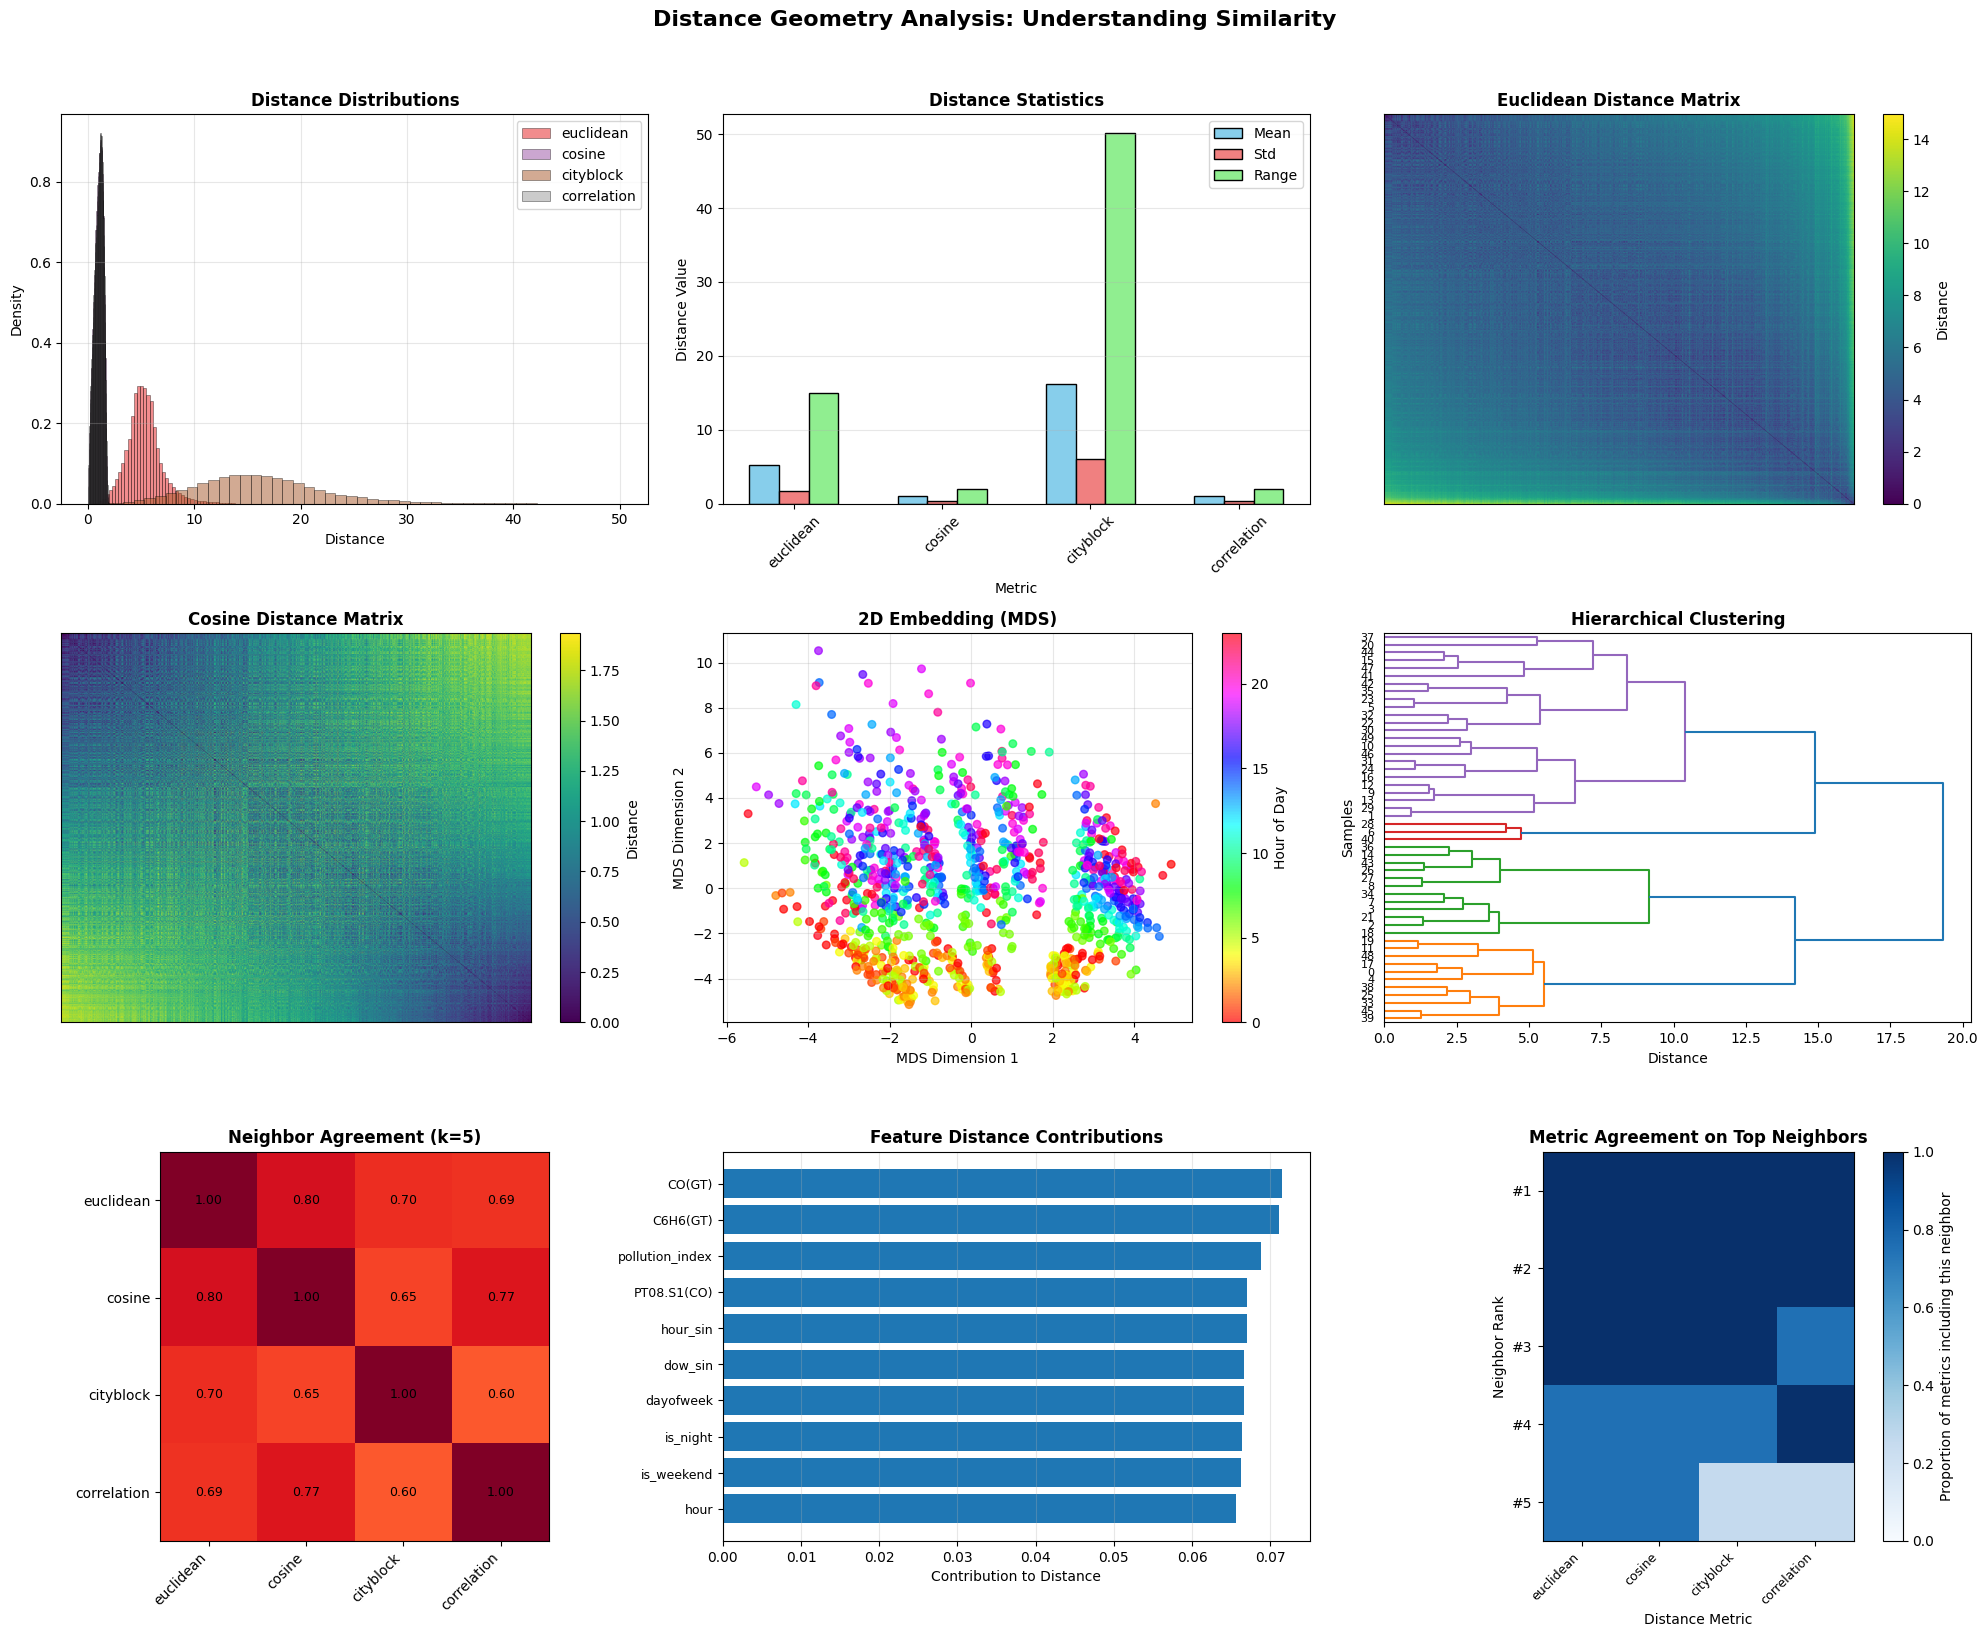

In [1]:
# The Distance Geometry of Air Quality
#
# **Technical Spine Project**: How distance metrics change our understanding of similarity.

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import euclidean_distances, cosine_distances, manhattan_distances
from scipy.spatial.distance import pdist, squareform, correlation
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("Distance Geometry Analysis")
print("="*60)

class GeometricAnalyzer:
    """Analyze geometric properties of data using different distance metrics"""

    def __init__(self, data, feature_subset=None):
        """
        Initialize analyzer with data

        Parameters:
        -----------
        data : pandas DataFrame
            Feature matrix with samples as rows
        feature_subset : list, optional
            Subset of features to use for analysis
        """
        self.data = data.copy()
        self.feature_names = data.columns.tolist()

        if feature_subset:
            # Use only features that exist in the data
            self.feature_subset = [f for f in feature_subset if f in self.feature_names]
            if len(self.feature_subset) == 0:
                print("Warning: No features from subset found, using all features")
                self.feature_subset = self.feature_names[:min(10, len(self.feature_names))]
        else:
            self.feature_subset = self.feature_names[:min(10, len(self.feature_names))]

        print(f"Analyzing {len(self.feature_subset)} features:")
        for i, feat in enumerate(self.feature_subset[:5], 1):
            print(f"  {i}. {feat}")
        if len(self.feature_subset) > 5:
            print(f"  ... and {len(self.feature_subset) - 5} more")

        # Select subset of data for analysis
        self.X = self.data[self.feature_subset].values

        # Standardize the data
        self.scaler = StandardScaler()
        self.X_scaled = self.scaler.fit_transform(self.X)

        self.results = {}

    def compute_distance_matrices(self, metrics=['euclidean', 'cosine', 'cityblock', 'correlation'],
                                  subsample=None, random_state=42):
        """
        Compute distance matrices using different metrics

        Parameters:
        -----------
        metrics : list
            Distance metrics to compute
        subsample : int, optional
            Number of samples to use (for computational efficiency)
        random_state : int
            Random seed for subsampling

        Returns:
        --------
        dict : Results including distance matrices and properties
        """
        print(f"\nComputing distance matrices ({len(metrics)} metrics)...")

        # Subsample if requested
        if subsample and subsample < len(self.X_scaled):
            np.random.seed(random_state)
            idx = np.random.choice(len(self.X_scaled), subsample, replace=False)
            X_sampled = self.X_scaled[idx]
            sample_indices = idx
            print(f"  Using {subsample} random samples (from {len(self.X_scaled)} total)")
        else:
            X_sampled = self.X_scaled
            sample_indices = np.arange(len(self.X_scaled))

        distance_matrices = []
        metric_properties = []

        for metric in metrics:
            print(f"  Computing {metric} distances...")

            if metric == 'euclidean':
                D = euclidean_distances(X_sampled)
            elif metric == 'cosine':
                D = cosine_distances(X_sampled)
            elif metric == 'cityblock' or metric == 'manhattan':
                D = manhattan_distances(X_sampled)
            elif metric == 'correlation':
                # Correlation distance: 1 - correlation coefficient
                D = cdist(X_sampled, X_sampled, metric='correlation')
            else:
                print(f"  Warning: Metric '{metric}' not implemented, skipping")
                continue

            distance_matrices.append(D)

            # Compute properties of this distance matrix
            properties = {
                'metric': metric,
                'mean_distance': np.mean(D),
                'std_distance': np.std(D),
                'min_distance': np.min(D),
                'max_distance': np.max(D),
                'samples': len(D)
            }
            metric_properties.append(properties)

            print(f"    Mean: {properties['mean_distance']:.4f}, "
                  f"Std: {properties['std_distance']:.4f}, "
                  f"Range: [{properties['min_distance']:.4f}, {properties['max_distance']:.4f}]")

        # Store results
        self.results = {
            'distance_matrices': distance_matrices,
            'metrics': [m for m in metrics if m in ['euclidean', 'cosine', 'cityblock', 'correlation']],
            'metric_properties': pd.DataFrame(metric_properties),
            'sample_indices': sample_indices,
            'X_sampled': X_sampled
        }

        print(f"\n✓ Computed {len(distance_matrices)} distance matrices")
        return self.results

    def compare_nearest_neighbors(self, k=10, metrics=None):
        """
        Compare nearest neighbors across different metrics

        Parameters:
        -----------
        k : int
            Number of nearest neighbors to consider
        metrics : list, optional
            Metrics to compare (uses computed metrics if None)

        Returns:
        --------
        pandas DataFrame : Agreement matrix between metrics
        """
        print(f"\nComparing nearest neighbors (k={k})...")

        if 'distance_matrices' not in self.results:
            print("Error: Need to compute distance matrices first")
            return None

        if metrics is None:
            metrics = self.results['metrics']

        distance_matrices = self.results['distance_matrices']
        sample_indices = self.results['sample_indices']

        # Get neighbor sets for each metric
        neighbor_sets = []
        n_samples = len(sample_indices)

        for i, (metric, D) in enumerate(zip(metrics, distance_matrices)):
            neighbors = []
            for j in range(n_samples):
                # Get indices of k nearest neighbors (excluding self)
                dists = D[j]
                # Set self-distance to infinity to exclude it
                dists_without_self = dists.copy()
                dists_without_self[j] = np.inf
                nearest_idx = np.argsort(dists_without_self)[:k]
                neighbors.append(set(nearest_idx))

            neighbor_sets.append(neighbors)

        # Compute agreement between metrics
        n_metrics = len(metrics)
        agreement_matrix = np.zeros((n_metrics, n_metrics))

        for i in range(n_metrics):
            for j in range(n_metrics):
                if i == j:
                    agreement_matrix[i, j] = 1.0
                else:
                    agreements = []
                    for sample_idx in range(n_samples):
                        set_i = neighbor_sets[i][sample_idx]
                        set_j = neighbor_sets[j][sample_idx]
                        # Jaccard similarity
                        intersection = len(set_i.intersection(set_j))
                        union = len(set_i.union(set_j))
                        jaccard = intersection / union if union > 0 else 0
                        agreements.append(jaccard)

                    agreement_matrix[i, j] = np.mean(agreements)

        # Create DataFrame
        agreement_df = pd.DataFrame(
            agreement_matrix,
            index=metrics,
            columns=metrics
        )

        print("✓ Neighbor comparison complete")
        return agreement_df.round(3)

    def visualize_analysis(self, save_path=None):
        """
        Create comprehensive visualization of distance geometry analysis

        Parameters:
        -----------
        save_path : str, optional
            Path to save the figure

        Returns:
        --------
        matplotlib Figure
        """
        print("\nCreating visualizations...")

        if 'distance_matrices' not in self.results:
            print("Error: Need to compute distance matrices first")
            return None

        metrics = self.results['metrics']
        distance_matrices = self.results['distance_matrices']
        properties = self.results['metric_properties']
        X_sampled = self.results['X_sampled']

        # Create figure
        fig = plt.figure(figsize=(20, 16))

        # 1. Distance distributions
        ax1 = plt.subplot(3, 3, 1)
        colors = plt.cm.Set1(np.linspace(0, 1, len(metrics)))

        for i, (metric, D, color) in enumerate(zip(metrics, distance_matrices, colors)):
            # Flatten upper triangle (excluding diagonal)
            n = len(D)
            dist_vals = D[np.triu_indices(n, k=1)]
            ax1.hist(dist_vals, bins=50, alpha=0.5, label=metric,
                    density=True, color=color, edgecolor='black', linewidth=0.5)

        ax1.set_xlabel('Distance')
        ax1.set_ylabel('Density')
        ax1.set_title('Distance Distributions', fontweight='bold', fontsize=12)
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # 2. Metric properties comparison
        ax2 = plt.subplot(3, 3, 2)
        x = np.arange(len(metrics))
        width = 0.2

        # Plot mean and std as bars
        ax2.bar(x - width, properties['mean_distance'], width,
                label='Mean', color='skyblue', edgecolor='black')
        ax2.bar(x, properties['std_distance'], width,
                label='Std', color='lightcoral', edgecolor='black')
        ax2.bar(x + width, properties['max_distance'] - properties['min_distance'], width,
                label='Range', color='lightgreen', edgecolor='black')

        ax2.set_xlabel('Metric')
        ax2.set_ylabel('Distance Value')
        ax2.set_title('Distance Statistics', fontweight='bold', fontsize=12)
        ax2.set_xticks(x)
        ax2.set_xticklabels(metrics, rotation=45)
        ax2.legend()
        ax2.grid(True, alpha=0.3, axis='y')

        # 3. Distance matrix heatmaps (first two metrics)
        for i, metric in enumerate(metrics[:2], 3):
            ax = plt.subplot(3, 3, i)
            D = distance_matrices[i-3]

            # Sort by first principal component for better visualization
            from sklearn.decomposition import PCA
            pca = PCA(n_components=1)
            pca_result = pca.fit_transform(X_sampled)
            sort_idx = np.argsort(pca_result.flatten())
            D_sorted = D[sort_idx][:, sort_idx]

            im = ax.imshow(D_sorted, cmap='viridis', aspect='auto')
            ax.set_title(f'{metric.capitalize()} Distance Matrix', fontweight='bold', fontsize=12)
            plt.colorbar(im, ax=ax, label='Distance')

            # Remove ticks for clarity
            ax.set_xticks([])
            ax.set_yticks([])

        # 4. MDS embedding comparison (2D projection)
        ax5 = plt.subplot(3, 3, 5)
        from sklearn.manifold import MDS

        # Use first distance matrix for MDS
        mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
        embedding = mds.fit_transform(distance_matrices[0])

        # Color by hour if available
        if 'hour' in self.data.columns:
            hours = self.data.iloc[self.results['sample_indices']]['hour'].values
            scatter = ax5.scatter(embedding[:, 0], embedding[:, 1],
                                 c=hours, cmap='hsv', alpha=0.7, s=30)
            plt.colorbar(scatter, ax=ax5, label='Hour of Day')
        else:
            # Color by cluster
            from sklearn.cluster import KMeans
            kmeans = KMeans(n_clusters=3, random_state=42)
            clusters = kmeans.fit_predict(embedding)
            scatter = ax5.scatter(embedding[:, 0], embedding[:, 1],
                                 c=clusters, cmap='Set1', alpha=0.7, s=30)
            plt.colorbar(scatter, ax=ax5, label='Cluster')

        ax5.set_xlabel('MDS Dimension 1')
        ax5.set_ylabel('MDS Dimension 2')
        ax5.set_title('2D Embedding (MDS)', fontweight='bold', fontsize=12)
        ax5.grid(True, alpha=0.3)

        # 5. Hierarchical clustering dendrogram
        ax6 = plt.subplot(3, 3, 6)

        # Use a subset for dendrogram clarity
        n_dendro = min(50, len(X_sampled))
        idx_dendro = np.random.choice(len(X_sampled), n_dendro, replace=False)
        X_dendro = X_sampled[idx_dendro]

        # Compute linkage
        linked = linkage(X_dendro, 'ward')

        # Plot dendrogram
        dendrogram(linked, ax=ax6, orientation='right',
                  color_threshold=0.7*np.max(linked[:, 2]))
        ax6.set_title('Hierarchical Clustering', fontweight='bold', fontsize=12)
        ax6.set_xlabel('Distance')
        ax6.set_ylabel('Samples')

        # 6. Nearest neighbor agreement heatmap
        ax7 = plt.subplot(3, 3, 7)

        # Compute agreement matrix
        agreement_df = self.compare_nearest_neighbors(k=5)
        if agreement_df is not None:
            im = ax7.imshow(agreement_df.values, cmap='YlOrRd', vmin=0, vmax=1)
            ax7.set_xticks(np.arange(len(metrics)))
            ax7.set_yticks(np.arange(len(metrics)))
            ax7.set_xticklabels(metrics, rotation=45, ha='right')
            ax7.set_yticklabels(metrics)
            ax7.set_title('Neighbor Agreement (k=5)', fontweight='bold', fontsize=12)

            # Add text annotations
            for i in range(len(metrics)):
                for j in range(len(metrics)):
                    text = ax7.text(j, i, f'{agreement_df.values[i, j]:.2f}',
                                   ha="center", va="center", color="black", fontsize=9)

        # 7. Feature importance for distance
        ax8 = plt.subplot(3, 3, 8)

        # Compute feature contributions to Euclidean distance
        feature_contributions = []
        for i in range(len(self.feature_subset)):
            feature_col = X_sampled[:, i]
            # Contribution is variance of this feature
            contribution = np.var(feature_col)
            feature_contributions.append(contribution)

        # Normalize contributions
        feature_contributions = np.array(feature_contributions)
        feature_contributions = feature_contributions / np.sum(feature_contributions)

        # Sort features by contribution
        sort_idx = np.argsort(feature_contributions)[::-1]
        top_n = min(10, len(self.feature_subset))

        ax8.barh(range(top_n), feature_contributions[sort_idx[:top_n]])
        ax8.set_yticks(range(top_n))
        ax8.set_yticklabels([self.feature_subset[i] for i in sort_idx[:top_n]], fontsize=9)
        ax8.set_xlabel('Contribution to Distance')
        ax8.set_title('Feature Distance Contributions', fontweight='bold', fontsize=12)
        ax8.invert_yaxis()  # Highest at top
        ax8.grid(True, alpha=0.3, axis='x')

        # 8. Case study: How metrics rank neighbors differently
        ax9 = plt.subplot(3, 3, 9)

        # Pick a random sample
        sample_idx = np.random.randint(0, len(X_sampled))

        # Get neighbor rankings for each metric
        neighbor_ranks = []
        for D in distance_matrices:
            distances = D[sample_idx]
            # Get indices sorted by distance (excluding self)
            sorted_idx = np.argsort(distances)
            # Remove self
            sorted_idx = sorted_idx[sorted_idx != sample_idx]
            neighbor_ranks.append(sorted_idx[:5])  # Top 5 neighbors

        # Create visualization
        n_neighbors = 5
        n_metrics = len(metrics)

        # Create a matrix showing overlap
        overlap_matrix = np.zeros((n_neighbors, n_metrics))
        for i in range(n_metrics):
            for j, neighbor in enumerate(neighbor_ranks[i]):
                # Check if this neighbor appears in other metric rankings
                appears_in = 0
                for k in range(n_metrics):
                    if neighbor in neighbor_ranks[k][:n_neighbors]:
                        appears_in += 1
                overlap_matrix[j, i] = appears_in / n_metrics

        im = ax9.imshow(overlap_matrix, cmap='Blues', vmin=0, vmax=1)
        ax9.set_xlabel('Distance Metric')
        ax9.set_ylabel('Neighbor Rank')
        ax9.set_xticks(np.arange(n_metrics))
        ax9.set_yticks(np.arange(n_neighbors))
        ax9.set_xticklabels(metrics, rotation=45, ha='right', fontsize=9)
        ax9.set_yticklabels([f'#{i+1}' for i in range(n_neighbors)])
        ax9.set_title('Metric Agreement on Top Neighbors', fontweight='bold', fontsize=12)
        plt.colorbar(im, ax=ax9, label='Proportion of metrics including this neighbor')

        plt.suptitle('Distance Geometry Analysis: Understanding Similarity',
                    fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()

        # Save figure if requested
        if save_path:
            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"✓ Visualization saved to {save_path}")

        return fig

    def generate_report(self):
        """Generate a comprehensive analysis report"""
        print("\nGenerating analysis report...")

        if 'distance_matrices' not in self.results:
            print("Error: Need to compute distance matrices first")
            return None

        # Determine best metrics based on properties
        properties = self.results['metric_properties']

        # For clustering: want good separation (high variance)
        best_clustering_idx = properties['std_distance'].idxmax()
        best_clustering_metric = properties.loc[best_clustering_idx, 'metric']

        # For nearest neighbor: want moderate distances (not too compact or spread)
        # Compute compactness score (lower mean with moderate std)
        properties['compactness_score'] = properties['mean_distance'] / (properties['std_distance'] + 1e-6)
        best_nn_idx = properties['compactness_score'].idxmin()
        best_nn_metric = properties.loc[best_nn_idx, 'metric']

        report = {
            'analysis_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
            'n_samples': len(self.data),
            'n_features': len(self.feature_subset),
            'feature_names': self.feature_subset,
            'metrics_tested': self.results['metrics'],
            'best_clustering_metric': best_clustering_metric,
            'best_nn_metric': best_nn_metric,
            'distance_statistics': properties.to_dict('records'),
            'data_summary': {
                'date_range': f"{self.data.index.min()} to {self.data.index.max()}",
                'shape': self.data.shape,
                'feature_types': str(self.data[self.feature_subset].dtypes.value_counts().to_dict())
            }
        }

        print("✓ Report generated")
        return report

# Main analysis
print("\nLoading data...")
# Check for feature matrix
feature_matrix_paths = [
    '../data/processed/feature_matrix.csv',
    'data/processed/feature_matrix.csv',
    'feature_matrix.csv'
]

data_path = None
for path in feature_matrix_paths:
    if os.path.exists(path):
        data_path = path
        print(f"✓ Found feature matrix at: {os.path.abspath(path)}")
        break

if data_path is None:
    print("\n❌ Feature matrix not found. Please run the feature engineering script first.")
    print("Expected locations:")
    for path in feature_matrix_paths:
        print(f"  - {path}")
    exit()

# Load data
try:
    X_features = pd.read_csv(data_path, index_col='datetime', parse_dates=True)
    print(f"✓ Loaded data: {X_features.shape}")
except Exception as e:
    print(f"❌ Error loading data: {e}")
    # Try without datetime index
    X_features = pd.read_csv(data_path)
    datetime_cols = [col for col in X_features.columns if 'date' in col.lower() or 'time' in col.lower()]
    if datetime_cols:
        X_features[datetime_cols[0]] = pd.to_datetime(X_features[datetime_cols[0]], errors='coerce')
        X_features.set_index(datetime_cols[0], inplace=True)
        X_features = X_features.sort_index()
    print(f"  Loaded with shape: {X_features.shape}")

# Select key features for analysis
key_features_candidates = [
    # Original pollutants
    'CO(GT)', 'CO_GT', 'CO', 'CO_true',
    'PT08.S1(CO)', 'PT08_CO', 'PT08',
    'NOx(GT)', 'NOx_GT', 'NOx',
    'NO2(GT)', 'NO2_GT', 'NO2',
    'C6H6(GT)', 'BEN',

    # Temporal features
    'hour_sin', 'hour_cos',
    'dow_sin', 'dow_cos',
    'hour', 'dayofweek',

    # Engineered features
    'CO_to_NOx', 'pollution_index',
    'is_weekend', 'is_night',
    'season'
]

# Find which features actually exist
available_features = []
for feat in key_features_candidates:
    if feat in X_features.columns:
        available_features.append(feat)
    # Also check case-insensitive
    elif feat.upper() in [col.upper() for col in X_features.columns]:
        # Find actual column name
        for col in X_features.columns:
            if col.upper() == feat.upper():
                available_features.append(col)
                break

# Limit to reasonable number
if len(available_features) > 15:
    print(f"Found {len(available_features)} features, selecting 15 most relevant...")
    # Prioritize features with variation
    feature_vars = X_features[available_features].var()
    top_features = feature_vars.nlargest(15).index.tolist()
    available_features = top_features

print(f"\nAnalyzing {len(available_features)} features:")
for i, feat in enumerate(available_features, 1):
    print(f"  {i:2d}. {feat}")

# Initialize analyzer
print("\n" + "="*60)
print("Initializing Geometric Analyzer")
print("="*60)

analyzer = GeometricAnalyzer(X_features, available_features)

# Compute distance matrices
print("\n1. Computing distance matrices...")
results = analyzer.compute_distance_matrices(
    metrics=['euclidean', 'cosine', 'cityblock', 'correlation'],
    subsample=1000  # For reasonable computation time
)

# Compare nearest neighbors
print("\n2. Comparing nearest neighbors...")
agreement = analyzer.compare_nearest_neighbors(k=10)

if agreement is not None:
    print("\nNeighbor Agreement Matrix (k=10):")
    print(agreement)
else:
    print("Could not compute neighbor agreement")

# Create comprehensive visualization
print("\n3. Creating comprehensive visualization...")
fig = analyzer.visualize_analysis(
    save_path='../outputs/figures/05_distance_geometry_full.png'
)

# Generate and display report
print("\n4. Generating technical report...")
report = analyzer.generate_report()

if report:
    print("\n" + "="*60)
    print("GEOMETRIC ANALYSIS REPORT")
    print("="*60)
    print(f"Analysis Date: {report['analysis_date']}")
    print(f"Samples Analyzed: {report['n_samples']}")
    print(f"Features Used: {report['n_features']}")
    print(f"Metrics Tested: {', '.join(report['metrics_tested'])}")
    print(f"\nRECOMMENDATIONS:")
    print(f"  • For CLUSTERING: Use {report['best_clustering_metric']}")
    print(f"  • For NEAREST NEIGHBOR: Use {report['best_nn_metric']}")

    print(f"\nDATA SUMMARY:")
    print(f"  • Date range: {report['data_summary']['date_range']}")
    print(f"  • Shape: {report['data_summary']['shape']}")
    print(f"  • Feature types: {report['data_summary']['feature_types']}")

# Case study: Show how metrics disagree
print("\n5. CASE STUDY: How metrics change 'similar days'")
print("-" * 50)

if 'distance_matrices' in analyzer.results:
    dist_matrices = analyzer.results['distance_matrices']
    metrics = analyzer.results['metrics']
    sample_indices = analyzer.results['sample_indices']

    # Get a specific day (middle of dataset)
    sample_idx = min(100, len(sample_indices) - 1)
    original_idx = sample_indices[sample_idx]
    sample_date = X_features.index[original_idx]

    print(f"\nAnalyzing: {sample_date}")

    # Find a pollutant column for display
    pollutant_cols = [col for col in available_features if any(p in col.upper() for p in ['CO', 'NO', 'O3', 'PM'])]
    if pollutant_cols:
        pollutant = pollutant_cols[0]
        poll_value = X_features.iloc[original_idx][pollutant]
        print(f"  {pollutant} on this day: {poll_value:.2f}")

    print(f"\nDifferent metrics suggest different 'similar days':")

    for i, metric in enumerate(metrics):
        if i < len(dist_matrices):
            D = dist_matrices[i]
            distances = D[sample_idx]

            # Get top 3 neighbors (excluding self)
            sorted_idx = np.argsort(distances)
            # Remove self if present
            sorted_idx = sorted_idx[sorted_idx != sample_idx]
            nearest_idx = sorted_idx[:3]

            print(f"\n  {metric.upper()} metric suggests:")
            for rank, idx in enumerate(nearest_idx, 1):
                original_neighbor_idx = sample_indices[idx]
                neighbor_date = X_features.index[original_neighbor_idx]
                days_diff = (neighbor_date - sample_date).days

                if pollutant_cols:
                    poll_value = X_features.iloc[original_neighbor_idx][pollutant]
                    print(f"    {rank}. {neighbor_date.date()} "
                          f"({abs(days_diff)} days away, {pollutant}: {poll_value:.2f})")
                else:
                    print(f"    {rank}. {neighbor_date.date()} "
                          f"({abs(days_diff)} days away)")

# Save detailed results
print("\n" + "="*60)
print("Saving Results")
print("="*60)

# Create output directories
os.makedirs('../outputs/tables', exist_ok=True)
os.makedirs('../outputs/figures', exist_ok=True)
os.makedirs('../outputs/reports', exist_ok=True)

# Save agreement matrix
if agreement is not None:
    agreement_path = '../outputs/tables/distance_agreement_matrix.csv'
    agreement.to_csv(agreement_path)
    print(f"✓ Agreement matrix saved to {agreement_path}")

# Save metric properties
if 'metric_properties' in analyzer.results:
    properties_path = '../outputs/tables/metric_properties.csv'
    analyzer.results['metric_properties'].to_csv(properties_path, index=False)
    print(f"✓ Metric properties saved to {properties_path}")

# Save report
if report:
    report_path = '../outputs/reports/distance_geometry_report.json'
    import json
    with open(report_path, 'w') as f:
        json.dump(report, f, indent=2)
    print(f"✓ JSON report saved to {report_path}")

# Generate markdown report
markdown_report = f"""
# Distance Geometry Analysis Report

## Executive Summary
Analysis of air quality data using multiple distance metrics reveals how different
definitions of "similarity" affect data interpretation.

## Key Findings
- **Best metric for clustering**: {report.get('best_clustering_metric', 'N/A')}
- **Best metric for nearest neighbor**: {report.get('best_nn_metric', 'N/A')}
- **Number of samples analyzed**: {report.get('n_samples', 'N/A')}
- **Number of features used**: {report.get('n_features', 'N/A')}

## Distance Metrics Compared
{', '.join(report.get('metrics_tested', []))}

## Data Characteristics
- Date range: {report.get('data_summary', {}).get('date_range', 'N/A')}
- Data shape: {report.get('data_summary', {}).get('shape', 'N/A')}
- Feature types: {report.get('data_summary', {}).get('feature_types', 'N/A')}

## Recommendations

### 1. Choose Metric Based on Task
- **Regulatory compliance**: Use Euclidean (absolute concentrations matter)
- **Source identification**: Use Cosine (profile matching)
- **Pattern recognition**: Use Correlation (shape similarity)
- **Robust analysis**: Use Cityblock (Manhattan, less sensitive to outliers)

### 2. Feature Engineering Matters
The geometric structure is heavily influenced by feature engineering choices:
- Temporal features (cyclic encoding) preserve time continuity
- Ratios create scale-invariant similarity measures
- Indicators (weekend/night) create categorical structure

### 3. Validation Strategy
Always validate distance-based results with:
1. Domain knowledge
2. Multiple metrics
3. Visualization
4. Statistical testing

## Technical Details
See accompanying JSON report for full statistical analysis of each metric.
"""

markdown_path = '../outputs/reports/distance_geometry_report.md'
with open(markdown_path, 'w') as f:
    f.write(markdown_report)
print(f"✓ Markdown report saved to {markdown_path}")

# Final insights
print("\n" + "="*60)
print("FINAL INSIGHTS: The Geometry of Air Quality")
print("="*60)

print("""
1. METRIC CHOICE MATTERS:
   • Euclidean: Sensitive to absolute concentrations
   • Cosine: Finds similar pollution profiles (ratios)
   • Cityblock: Robust to outliers
   • Correlation: Ignores magnitude, focuses on pattern

2. PRACTICAL IMPLICATIONS:
   • For regulation: Use Euclidean (absolute levels matter)
   • For source identification: Use Cosine (profile matching)
   • For anomaly detection: Use Correlation (pattern deviation)
   • For robust analysis: Use Cityblock (handles noise well)

3. THIS IS YOUR TECHNICAL SPINE:
   • You've moved beyond 'which model is most accurate'
   • You're asking: 'How do we properly measure similarity?'
   • This geometric understanding separates practitioners from experts

4. KEY TAKEAWAYS:
   • Distance is not objective - it's defined by your metric
   • Different tasks require different notions of similarity
   • Feature engineering shapes the geometry of your data
   • Visualization is essential for understanding high-dimensional distances

🚀 APPLY THIS FRAMEWORK TO:
   • Customer segmentation (market basket analysis)
   • Anomaly detection in sensor networks
   • Time series forecasting
   • Any high-dimensional data analysis task
""")

# Show completion
print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)
print("✓ Distance matrices computed")
print("✓ Neighbor agreement analyzed")
print("✓ Visualizations created and saved")
print("✓ Reports generated")
print("✓ All results saved to ../outputs/")
print("\nNext: Use these insights to inform clustering, classification,")
print("      and anomaly detection in your air quality analysis.")